# CS514 User Archetype Analysis

This notebook inspects the user taste profiles derived from the validated midline game communities.

Inputs are generated by:

- `scripts/cs514_build_user_profiles.py`
- `scripts/cs514_analyze_user_archetypes.py`

Goal: decide which user-level findings are strong enough for the report/poster, and identify which patterns are artifacts of the `other` catch-all bucket.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RUN_LABEL = "merged_ownership_newman_disparity_a0p025_r1p75"
INCIDENCE_LABEL = "merged_ownership"
PREFIX = f"{RUN_LABEL}_{INCIDENCE_LABEL}"

PROFILE_DIR = PROJECT_ROOT / "data" / "processed" / "cs514_network_analysis" / "user_profiles"
FIG_DIR = PROJECT_ROOT / "data" / "processed" / "cs514_network_analysis" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

paths = {
    "profiles": PROFILE_DIR / f"{PREFIX}_user_profiles.csv",
    "archetypes": PROFILE_DIR / f"{PREFIX}_user_archetypes.csv",
    "archetype_summary": PROFILE_DIR / f"{PREFIX}_archetype_summary.csv",
    "family_summary": PROFILE_DIR / f"{PREFIX}_archetype_family_summary.csv",
    "dimension_summary": PROFILE_DIR / f"{PREFIX}_archetype_dimension_summary.csv",
    "top_games": PROFILE_DIR / f"{PREFIX}_archetype_top_games.csv",
    "other_decomposition": PROFILE_DIR / f"{PREFIX}_other_dominant_decomposition.csv",
    "other_users": PROFILE_DIR / f"{PREFIX}_other_dominant_users.csv",
    "game_mapping": PROFILE_DIR / f"{PREFIX}_game_profile_mapping.csv",
}

for name, path in paths.items():
    print(f"{name:22s} {path.exists()}  {path}")

profiles               True  C:\Users\suuser\Desktop\Practices\bgg_project\data\processed\cs514_network_analysis\user_profiles\merged_ownership_newman_disparity_a0p025_r1p75_merged_ownership_user_profiles.csv
archetypes             True  C:\Users\suuser\Desktop\Practices\bgg_project\data\processed\cs514_network_analysis\user_profiles\merged_ownership_newman_disparity_a0p025_r1p75_merged_ownership_user_archetypes.csv
archetype_summary      True  C:\Users\suuser\Desktop\Practices\bgg_project\data\processed\cs514_network_analysis\user_profiles\merged_ownership_newman_disparity_a0p025_r1p75_merged_ownership_archetype_summary.csv
family_summary         True  C:\Users\suuser\Desktop\Practices\bgg_project\data\processed\cs514_network_analysis\user_profiles\merged_ownership_newman_disparity_a0p025_r1p75_merged_ownership_archetype_family_summary.csv
dimension_summary      True  C:\Users\suuser\Desktop\Practices\bgg_project\data\processed\cs514_network_analysis\user_profiles\merged_ownership_new

## Load Outputs

In [2]:
profiles = pd.read_csv(paths["profiles"])
users = pd.read_csv(paths["archetypes"])
archetype_summary = pd.read_csv(paths["archetype_summary"])
family_summary = pd.read_csv(paths["family_summary"])
dimension_summary = pd.read_csv(paths["dimension_summary"])
top_games = pd.read_csv(paths["top_games"])
other_decomp = pd.read_csv(paths["other_decomposition"])
other_users = pd.read_csv(paths["other_users"])
game_mapping = pd.read_csv(paths["game_mapping"])

print("profiles", profiles.shape)
print("users", users.shape)
print("eligible users", int(users["eligible_for_archetype"].sum()))
print("filtered users", int((~users["eligible_for_archetype"]).sum()))

profiles (5504, 32)
users (5504, 37)
eligible users 5125
filtered users 379


## Quick Sanity Tables

Use these first to verify the broad interpretation before looking at charts.

In [3]:
family_summary

,archetype_family,n_users,eligible_users,pct_all_users,pct_eligible_users,median_selected_owned,mean_selected_owned,mean_included_share,median_included_share,mean_entropy,median_entropy,mean_dominant_share,median_dominant_share
0,other_dominant,3221,3221,0.585211,0.628488,97.0,129.202422,0.651225,0.666667,0.761153,0.776934,0.348775,0.333333
1,generalist,723,723,0.131359,0.141073,134.0,173.214385,0.813160,0.811828,0.809216,0.804843,0.258158,0.255507
2,leaning,634,634,0.115189,0.123707,65.0,87.922713,0.795267,0.793103,0.690338,0.701663,0.333842,0.340213
3,specialist,524,524,0.095203,0.102244,51.0,73.179389,0.862533,0.873563,0.547160,0.566307,0.525339,0.490259
4,mixed,23,23,0.004179,0.004488,41.0,67.478261,0.821864,0.814516,0.719401,0.730232,0.226856,0.227273
5,insufficient_selected_owned,379,0,0.068859,0.000000,7.0,7.506596,0.704077,0.785714,0.382557,0.418414,0.582819,0.500000


In [4]:
archetype_summary.head(25)

,archetype,n_users,pct_eligible_users,median_selected_owned,mean_selected_owned,mean_included_share,median_included_share,mean_entropy,median_entropy,mean_dominant_share,median_dominant_share,most_common_dominant_dimension,most_common_taste_dimension
0,other_dominant_mixed,3018,0.588878,102.0,134.549039,0.666101,0.671642,0.774610,0.784274,0.333899,0.328358,other,current_heavy_euro_engine_builders
1,generalist,723,0.141073,134.0,173.214385,0.813160,0.811828,0.809216,0.804843,0.258158,0.255507,bgg_golden_age_canon,bgg_golden_age_canon
2,other_dominant_low_coverage,203,0.039610,41.0,49.714286,0.430059,0.441176,0.561080,0.573051,0.569941,0.558824,other,current_heavy_euro_engine_builders
3,specialist__bgg_golden_age_canon,190,0.037073,73.0,104.194737,0.881340,0.884931,0.572021,0.584646,0.525374,0.493704,bgg_golden_age_canon,bgg_golden_age_canon
4,leaning__bgg_golden_age_canon,161,0.031415,89.0,117.590062,0.823954,0.827160,0.695465,0.700222,0.340365,0.348214,bgg_golden_age_canon,bgg_golden_age_canon
5,leaning__amerithrash_miniatures_lcg,141,0.027512,52.0,67.482270,0.796152,0.795918,0.681518,0.694574,0.324377,0.323944,amerithrash_miniatures_lcg,amerithrash_miniatures_lcg
6,specialist__amerithrash_miniatures_lcg,105,0.020488,34.0,49.857143,0.868792,0.878788,0.539122,0.553945,0.512614,0.483871,amerithrash_miniatures_lcg,amerithrash_miniatures_lcg
7,leaning__dungeon_crawl_cooperative_campaign_adventure,100,0.019512,61.5,76.650000,0.774619,0.771520,0.693343,0.701343,0.337387,0.344457,dungeon_crawl_cooperative_campaign_adventure,dungeon_crawl_cooperative_campaign_adventure
8,leaning__current_heavy_euro_engine_builders,99,0.019317,74.0,93.686869,0.756606,0.750000,0.691912,0.707457,0.339744,0.346939,current_heavy_euro_engine_builders,current_heavy_euro_engine_builders
9,specialist__historical_wargames_conflict_strategy,89,0.017366,43.0,55.235955,0.902334,0.909091,0.491003,0.524371,0.574950,0.500000,historical_wargames_conflict_strategy,historical_wargames_conflict_strategy


## Archetype Family Counts

This is the poster-level user-profile summary. Treat `other_dominant` as a diagnostic family, not as a single taste tribe.

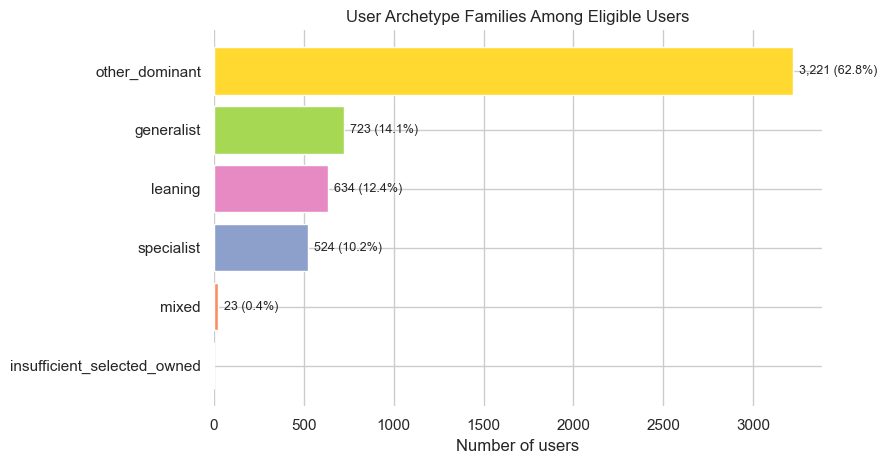

In [5]:
plot_df = family_summary.copy()
plot_df = plot_df.sort_values("eligible_users", ascending=True)

fig, ax = plt.subplots(figsize=(9, 4.8))
colors = sns.color_palette("Set2", n_colors=len(plot_df))
ax.barh(plot_df["archetype_family"], plot_df["eligible_users"], color=colors)
for i, row in enumerate(plot_df.itertuples(index=False)):
    if row.eligible_users > 0:
        ax.text(row.eligible_users + 35, i, f"{row.eligible_users:,} ({row.pct_eligible_users:.1%})", va="center", fontsize=9)
ax.set_title("User Archetype Families Among Eligible Users")
ax.set_xlabel("Number of users")
ax.set_ylabel("")
sns.despine(left=True, bottom=True)
fig.tight_layout()
fig.savefig(FIG_DIR / "user_archetype_family_counts.png", dpi=200, bbox_inches="tight")
plt.show()

## Taste Dimension Reach And Dominance

`users_with_any` measures how broadly a dimension appears. `dominant_taste_users` asks: ignoring `other`, which taste dimension is each user's strongest named dimension?

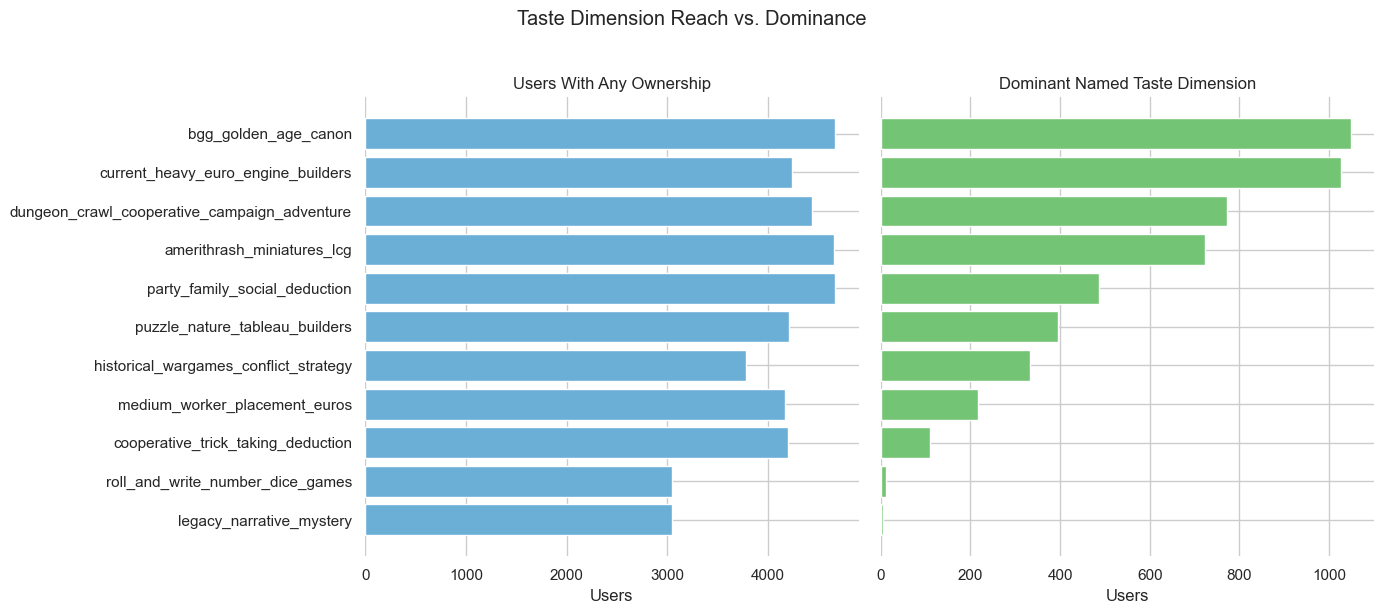

,dimension,users_with_any,pct_users_with_any,mean_share,median_nonzero_share,users_with_25pct_or_more,users_with_40pct_or_more,dominant_users,dominant_taste_users
0,bgg_golden_age_canon,4664,0.910049,0.112015,0.084507,558,192,571,1048
1,current_heavy_euro_engine_builders,4238,0.826927,0.089905,0.083333,350,41,277,1026
2,dungeon_crawl_cooperative_campaign_adventure,4440,0.866341,0.086365,0.069280,319,87,241,772
3,amerithrash_miniatures_lcg,4650,0.907317,0.094460,0.072165,387,106,386,724
4,party_family_social_deduction,4661,0.909463,0.077312,0.071429,102,7,78,486
5,puzzle_nature_tableau_builders,4202,0.819902,0.060319,0.060130,56,2,15,395
6,historical_wargames_conflict_strategy,3782,0.737951,0.058451,0.040816,235,90,233,334
7,medium_worker_placement_euros,4166,0.812878,0.061072,0.057497,87,5,96,216
8,cooperative_trick_taking_deduction,4193,0.818146,0.043899,0.042857,10,0,6,109
9,roll_and_write_number_dice_games,3046,0.594341,0.015271,0.019473,1,0,0,11


In [6]:
dim_plot = dimension_summary.sort_values("dominant_taste_users", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
axes[0].barh(dim_plot["dimension"], dim_plot["users_with_any"], color="#6BAED6")
axes[0].set_title("Users With Any Ownership")
axes[0].set_xlabel("Users")
axes[0].set_ylabel("")

axes[1].barh(dim_plot["dimension"], dim_plot["dominant_taste_users"], color="#74C476")
axes[1].set_title("Dominant Named Taste Dimension")
axes[1].set_xlabel("Users")
axes[1].set_ylabel("")

fig.suptitle("Taste Dimension Reach vs. Dominance", y=1.02)
sns.despine(left=True, bottom=True)
fig.tight_layout()
fig.savefig(FIG_DIR / "user_taste_dimension_reach_dominance.png", dpi=200, bbox_inches="tight")
plt.show()

dimension_summary

## Specialist And Leaning Users By Dimension

This view separates strong specialists from users who merely lean toward a dimension.

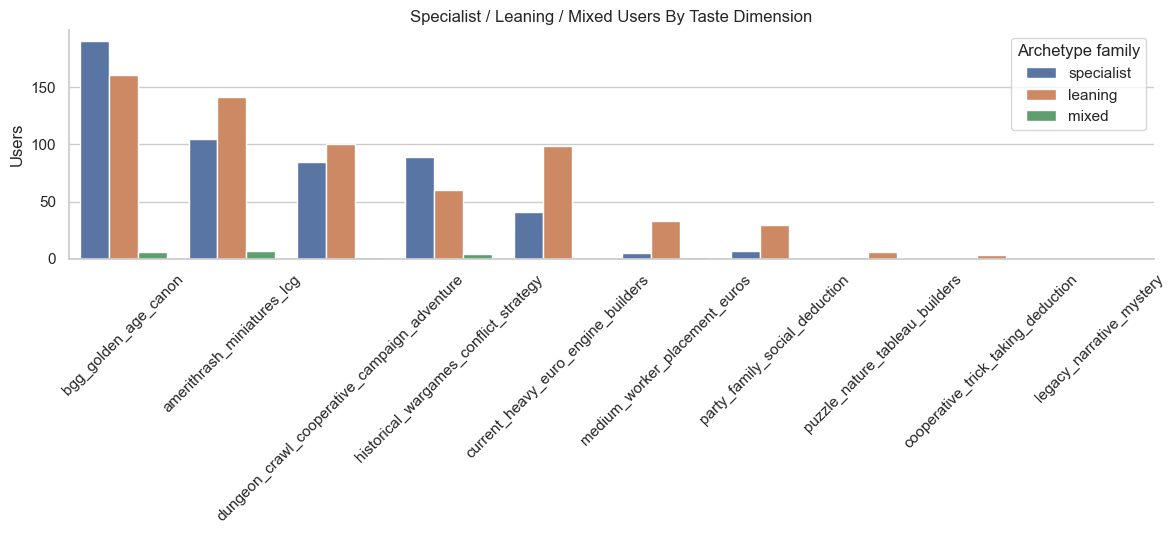

,family,dimension,n_users
8,leaning,bgg_golden_age_canon,161
9,leaning,amerithrash_miniatures_lcg,141
10,leaning,dungeon_crawl_cooperative_campaign_adventure,100
11,leaning,current_heavy_euro_engine_builders,99
12,leaning,historical_wargames_conflict_strategy,60
13,leaning,medium_worker_placement_euros,33
14,leaning,party_family_social_deduction,30
15,leaning,puzzle_nature_tableau_builders,6
16,leaning,cooperative_trick_taking_deduction,3
17,leaning,legacy_narrative_mystery,1


In [7]:
eligible = users[users["eligible_for_archetype"]].copy()

rows = []
for label in ["specialist", "leaning", "mixed"]:
    sub = eligible[eligible["archetype_family"].eq(label)]
    counts = sub["dominant_taste_dimension"].value_counts()
    for dim, count in counts.items():
        rows.append({"family": label, "dimension": dim, "n_users": count})

taste_family_dim = pd.DataFrame(rows)
if not taste_family_dim.empty:
    order = (
        taste_family_dim.groupby("dimension")["n_users"].sum().sort_values(ascending=False).index.tolist()
    )
    fig, ax = plt.subplots(figsize=(12, 5.5))
    sns.barplot(data=taste_family_dim, x="dimension", y="n_users", hue="family", order=order, ax=ax)
    ax.set_title("Specialist / Leaning / Mixed Users By Taste Dimension")
    ax.set_xlabel("")
    ax.set_ylabel("Users")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(title="Archetype family")
    sns.despine()
    fig.tight_layout()
    fig.savefig(FIG_DIR / "user_specialist_leaning_by_dimension.png", dpi=200, bbox_inches="tight")
    plt.show()

taste_family_dim.sort_values(["family", "n_users"], ascending=[True, False])

## Profile Shape: Concentration vs. Breadth

Entropy near 0 means narrow/specialized. Entropy near 1 means broad/generalist. Dominant share measures how much of a user's selected ownership sits in their largest profile dimension.

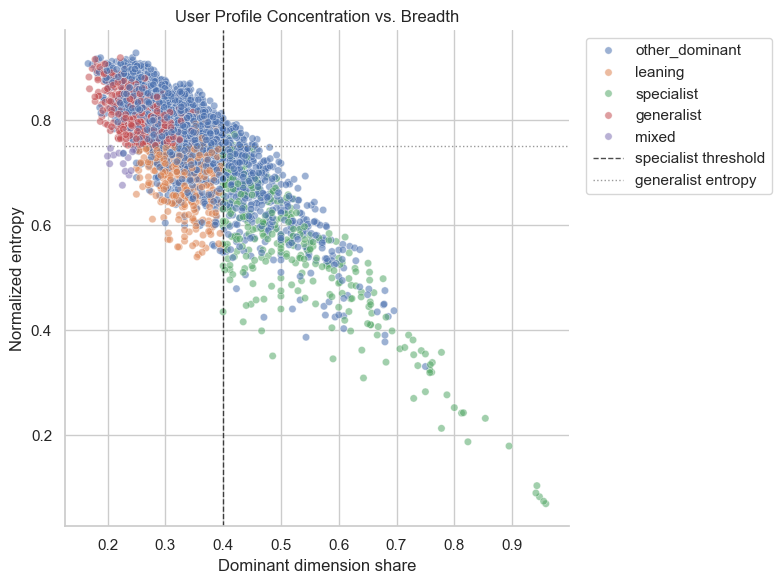

In [8]:
scatter = eligible.copy()
if len(scatter) > 3000:
    scatter = scatter.sample(3000, random_state=514)

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=scatter,
    x="dominant_share",
    y="profile_entropy_norm",
    hue="archetype_family",
    alpha=0.55,
    s=28,
    ax=ax,
)
ax.axvline(0.40, color="black", linestyle="--", linewidth=1, alpha=0.7, label="specialist threshold")
ax.axhline(0.75, color="gray", linestyle=":", linewidth=1, alpha=0.8, label="generalist entropy")
ax.set_title("User Profile Concentration vs. Breadth")
ax.set_xlabel("Dominant dimension share")
ax.set_ylabel("Normalized entropy")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
sns.despine()
fig.tight_layout()
fig.savefig(FIG_DIR / "user_profile_entropy_vs_dominant_share.png", dpi=200, bbox_inches="tight")
plt.show()

## Included Share

`included_share` is the fraction of a user's selected ownership covered by the manually accepted taste dimensions. Low values mean the user's collection is mostly in bridge/franchise/temporal/tiny communities.

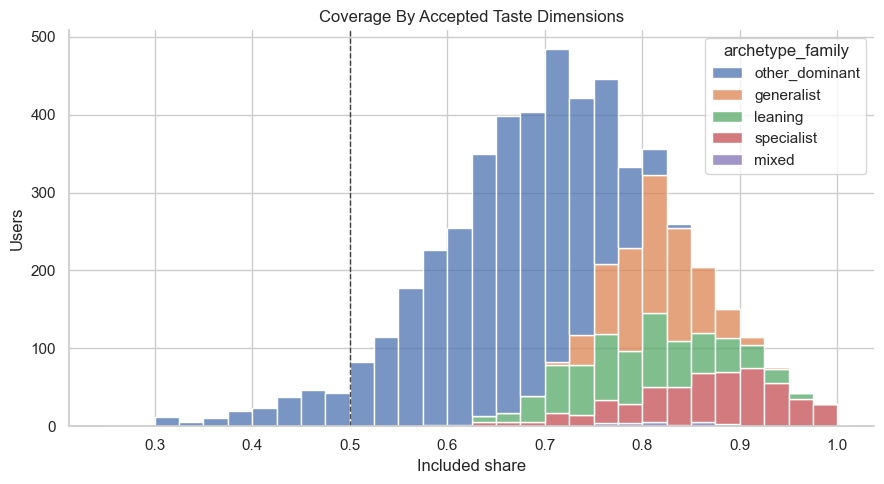

included_share               profile_entropy_norm         \
                          count median   mean                count median   
archetype_family                                                            
generalist                  723  0.812  0.813                  723  0.805   
leaning                     634  0.793  0.795                  634  0.702   
mixed                        23  0.815  0.822                   23  0.730   
other_dominant             3221  0.667  0.651                 3221  0.777   
specialist                  524  0.874  0.863                  524  0.566   

                        dominant_share               total_selected_owned  \
                   mean          count median   mean                count   
archetype_family                                                            
generalist        0.809            723  0.256  0.258                  723   
leaning           0.690            634  0.340  0.334                  634   
mixed             0.719             23  0.227  0.227                   23   
other_dominant    0.761           3221  0.333  0.349                 3221   
specialist        0.547            524  0.490  0.525                  524   

                                  
                 median     mean  
archetype_family                  
generalist        134.0  173.214  
leaning            65.0   87.923  
mixed              41.0   67.478  
other_dominant     97.0  129.202  
specialist         51.0   73.179

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(data=eligible, x="included_share", hue="archetype_family", bins=30, multiple="stack", ax=ax)
ax.axvline(0.50, color="black", linestyle="--", linewidth=1, alpha=0.7)
ax.set_title("Coverage By Accepted Taste Dimensions")
ax.set_xlabel("Included share")
ax.set_ylabel("Users")
sns.despine()
fig.tight_layout()
fig.savefig(FIG_DIR / "user_included_share_histogram.png", dpi=200, bbox_inches="tight")
plt.show()

eligible.groupby("archetype_family")[["included_share", "profile_entropy_norm", "dominant_share", "total_selected_owned"]].agg(["count", "median", "mean"]).round(3)

## What Is Inside `other`?

This section is important. `other` is not one taste group. It includes recent-release temporal clusters, bridge games, franchise/series clusters, tiny fragments, and unresolved review groups.

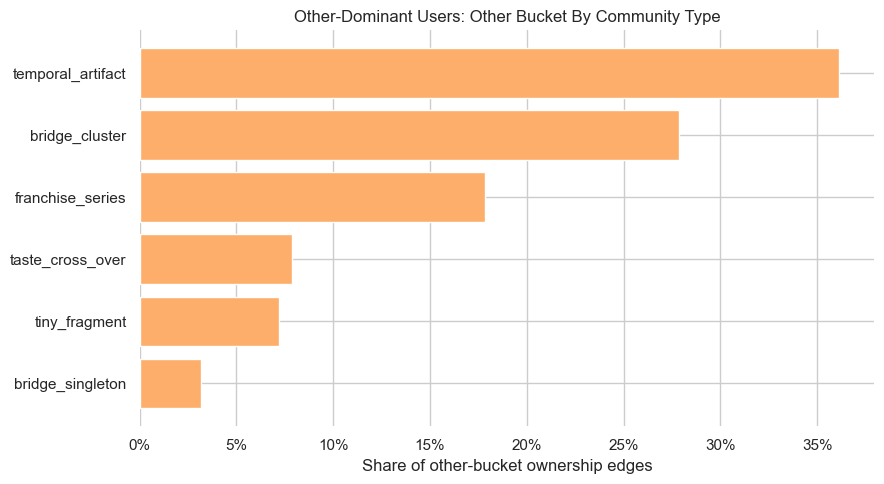

,group,value,owned_edges,share_of_other_owned_edges
6,manual_label,Recent releases / new-hotness cluster,47688,0.361232
7,manual_label,unlabeled,9486,0.071855
8,manual_label,Fantasy adventure / deck-building gateway,8669,0.065667
9,manual_label,Area-control crossover / Root-Eclipse cluster,8078,0.061190
10,manual_label,Unmatched / skirmish series cluster,3772,0.028573
11,manual_label,Light set-collection gateway,3603,0.027292
12,manual_label,Racing / sports / route bridge,3455,0.026171
13,manual_label,Licensed family/fandom games,3214,0.024346
14,manual_label,Pandemic system cluster,3116,0.023603
15,manual_label,Escape-room / Unlock series cluster,2896,0.021937


In [10]:
type_decomp = other_decomp[other_decomp["group"].eq("community_type")].sort_values("owned_edges", ascending=True)
label_decomp = other_decomp[other_decomp["group"].eq("manual_label")].sort_values("owned_edges", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(type_decomp["value"], type_decomp["share_of_other_owned_edges"], color="#FDAE6B")
ax.set_title("Other-Dominant Users: Other Bucket By Community Type")
ax.set_xlabel("Share of other-bucket ownership edges")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
sns.despine(left=True, bottom=True)
fig.tight_layout()
fig.savefig(FIG_DIR / "other_dominant_by_community_type.png", dpi=200, bbox_inches="tight")
plt.show()

label_decomp.head(20)

## Top Games By Archetype

Change `ARCHETYPE_TO_INSPECT` to inspect a specific group. Use values from `archetype_summary["archetype"]`.

In [11]:
archetype_summary[["archetype", "n_users", "median_selected_owned", "mean_included_share", "mean_entropy", "mean_dominant_share"]].head(30)

,archetype,n_users,median_selected_owned,mean_included_share,mean_entropy,mean_dominant_share
0,other_dominant_mixed,3018,102.0,0.666101,0.774610,0.333899
1,generalist,723,134.0,0.813160,0.809216,0.258158
2,other_dominant_low_coverage,203,41.0,0.430059,0.561080,0.569941
3,specialist__bgg_golden_age_canon,190,73.0,0.881340,0.572021,0.525374
4,leaning__bgg_golden_age_canon,161,89.0,0.823954,0.695465,0.340365
5,leaning__amerithrash_miniatures_lcg,141,52.0,0.796152,0.681518,0.324377
6,specialist__amerithrash_miniatures_lcg,105,34.0,0.868792,0.539122,0.512614
7,leaning__dungeon_crawl_cooperative_campaign_adventure,100,61.5,0.774619,0.693343,0.337387
8,leaning__current_heavy_euro_engine_builders,99,74.0,0.756606,0.691912,0.339744
9,specialist__historical_wargames_conflict_strategy,89,43.0,0.902334,0.491003,0.574950


In [12]:
ARCHETYPE_TO_INSPECT = "specialist__historical_wargames_conflict_strategy"

cols = [
    "within_archetype_rank",
    "name",
    "overall_rank",
    "owner_count_in_archetype",
    "owner_share_in_archetype",
    "profile_dimension",
    "manual_label",
    "community_type",
]
top_games[top_games["archetype"].eq(ARCHETYPE_TO_INSPECT)][cols].head(30)

,within_archetype_rank,name,overall_rank,owner_count_in_archetype,owner_share_in_archetype,profile_dimension,manual_label,community_type
280,1,Twilight Struggle,14,57,0.640449,historical_wargames_conflict_strategy,Historical wargames + conflict strategy,taste_specialist
281,2,Paths of Glory,262,42,0.471910,historical_wargames_conflict_strategy,Historical wargames + conflict strategy,taste_specialist
282,3,Maria,431,35,0.393258,historical_wargames_conflict_strategy,Historical wargames + conflict strategy,taste_specialist
283,4,Hannibal: Rome vs. Carthage,484,34,0.382022,historical_wargames_conflict_strategy,Historical wargames + conflict strategy,taste_specialist
284,5,Wilderness War,1403,33,0.370787,historical_wargames_conflict_strategy,Historical wargames + conflict strategy,taste_specialist
285,6,Empire of the Sun: The Pacific War 1941-1945,892,33,0.370787,historical_wargames_conflict_strategy,Historical wargames + conflict strategy,taste_specialist
286,7,War of the Ring: Second Edition,8,31,0.348315,historical_wargames_conflict_strategy,Historical wargames + conflict strategy,taste_specialist
287,8,1830: Railways & Robber Barons,311,31,0.348315,historical_wargames_conflict_strategy,Historical wargames + conflict strategy,taste_specialist
288,9,For the People,1384,31,0.348315,historical_wargames_conflict_strategy,Historical wargames + conflict strategy,taste_specialist
289,10,Washington's War,1073,30,0.337079,historical_wargames_conflict_strategy,Historical wargames + conflict strategy,taste_specialist


## Compare Representative Archetypes

This gives quick examples for the poster or writeup. The chosen list can be edited after inspection.

In [13]:
representative_archetypes = [
    "specialist__historical_wargames_conflict_strategy",
    "specialist__bgg_golden_age_canon",
    "specialist__amerithrash_miniatures_lcg",
    "specialist__dungeon_crawl_cooperative_campaign_adventure",
    "leaning__current_heavy_euro_engine_builders",
    "generalist",
]

comparison = top_games[top_games["archetype"].isin(representative_archetypes)].copy()
comparison = comparison[comparison["within_archetype_rank"] <= 10]
comparison.pivot_table(
    index="within_archetype_rank",
    columns="archetype",
    values="name",
    aggfunc="first",
)

archetype,generalist,leaning__current_heavy_euro_engine_builders,specialist__amerithrash_miniatures_lcg,specialist__bgg_golden_age_canon,specialist__dungeon_crawl_cooperative_campaign_adventure,specialist__historical_wargames_conflict_strategy
within_archetype_rank,,,,,,
1,Codenames,Terraforming Mars,Descent: Journeys in the Dark (Second Edition),Puerto Rico,Spirit Island,Twilight Struggle
2,Terraforming Mars,Ark Nova,Lords of Waterdeep,Catan,Gloomhaven: Jaws of the Lion,Paths of Glory
3,Carcassonne,Underwater Cities,Pandemic,Bohnanza,Marvel Champions: The Card Game,Maria
4,Pandemic,On Mars,Arkham Horror,Carcassonne,Gloomhaven,Hannibal: Rome vs. Carthage
5,Power Grid,Brass: Birmingham,Mage Knight Board Game,Tigris & Euphrates,Too Many Bones,Wilderness War
6,7 Wonders Duel,Nucleum,Eldritch Horror,Power Grid,Robinson Crusoe: Adventures on the Cursed Island,Empire of the Sun: The Pacific War 1941-1945
7,Azul,Praga Caput Regni,Star Wars: Imperial Assault,Ra,Aeon's End,War of the Ring: Second Edition
8,Puerto Rico,Gaia Project,Twilight Imperium: Third Edition,Lost Cities,Final Girl,1830: Railways & Robber Barons
9,Twilight Struggle,Grand Austria Hotel,Star Wars: Rebellion,El Grande,Arkham Horror: The Card Game,For the People


## Other-Dominant Users: Subtypes To Inspect

These users are dominated by `other`, but their strongest `other` source can differ: recent releases, bridge games, franchise/series ownership, or tiny fragments.

In [14]:
other_users.groupby("top_other_community_type").agg(
    n_users=("username", "count"),
    median_selected_owned=("total_selected_owned", "median"),
    median_other_owned=("other_owned_count", "median"),
    median_top_type_share=("top_other_community_type_share", "median"),
    common_taste_dimension=("dominant_taste_dimension", lambda s: s.mode().iat[0] if not s.mode().empty else ""),
).sort_values("n_users", ascending=False)

,n_users,median_selected_owned,median_other_owned,median_top_type_share,common_taste_dimension
top_other_community_type,,,,,
temporal_artifact,1657,105.0,38.0,0.480000,current_heavy_euro_engine_builders
bridge_cluster,1183,93.0,29.0,0.391304,current_heavy_euro_engine_builders
franchise_series,319,70.0,25.0,0.386364,party_family_social_deduction
tiny_fragment,29,36.0,14.0,0.300000,current_heavy_euro_engine_builders
taste_cross_over,27,44.0,14.0,0.375000,amerithrash_miniatures_lcg
bridge_singleton,6,26.0,9.0,0.240385,dungeon_crawl_cooperative_campaign_adventure


In [15]:
other_users.groupby("top_other_manual_label").agg(
    n_users=("username", "count"),
    median_selected_owned=("total_selected_owned", "median"),
    median_top_label_share=("top_other_manual_label_share", "median"),
    common_taste_dimension=("dominant_taste_dimension", lambda s: s.mode().iat[0] if not s.mode().empty else ""),
).sort_values("n_users", ascending=False).head(25)

,n_users,median_selected_owned,median_top_label_share,common_taste_dimension
top_other_manual_label,,,,
Recent releases / new-hotness cluster,2404,109.0,0.400000,current_heavy_euro_engine_builders
unlabeled,297,61.0,0.181818,bgg_golden_age_canon
Fantasy adventure / deck-building gateway,181,97.0,0.200000,amerithrash_miniatures_lcg
Area-control crossover / Root-Eclipse cluster,109,66.0,0.238095,amerithrash_miniatures_lcg
Unmatched / skirmish series cluster,53,86.0,0.296296,amerithrash_miniatures_lcg
Take-that card/fandom cluster,21,56.0,0.250000,amerithrash_miniatures_lcg
Light set-collection gateway,20,59.0,0.219807,party_family_social_deduction
Escape-room / Unlock series cluster,18,78.0,0.293403,party_family_social_deduction
Licensed family/fandom games,14,38.0,0.205263,dungeon_crawl_cooperative_campaign_adventure


## Export-Ready Tables

These smaller tables are useful for report writing and poster drafting.

In [16]:
poster_family_table = family_summary[[
    "archetype_family",
    "eligible_users",
    "pct_eligible_users",
    "median_selected_owned",
    "mean_included_share",
    "mean_entropy",
    "mean_dominant_share",
]].copy()
poster_family_table["pct_eligible_users"] = poster_family_table["pct_eligible_users"].map(lambda x: f"{x:.1%}")
poster_family_table.round(3)

,archetype_family,eligible_users,pct_eligible_users,median_selected_owned,mean_included_share,mean_entropy,mean_dominant_share
0,other_dominant,3221,62.8%,97.0,0.651,0.761,0.349
1,generalist,723,14.1%,134.0,0.813,0.809,0.258
2,leaning,634,12.4%,65.0,0.795,0.690,0.334
3,specialist,524,10.2%,51.0,0.863,0.547,0.525
4,mixed,23,0.4%,41.0,0.822,0.719,0.227
5,insufficient_selected_owned,0,0.0%,7.0,0.704,0.383,0.583


In [17]:
poster_dimension_table = dimension_summary[[
    "dimension",
    "users_with_any",
    "pct_users_with_any",
    "dominant_taste_users",
    "users_with_25pct_or_more",
    "users_with_40pct_or_more",
    "mean_share",
]].copy()
poster_dimension_table["pct_users_with_any"] = poster_dimension_table["pct_users_with_any"].map(lambda x: f"{x:.1%}")
poster_dimension_table.round(3)

,dimension,users_with_any,pct_users_with_any,dominant_taste_users,users_with_25pct_or_more,users_with_40pct_or_more,mean_share
0,bgg_golden_age_canon,4664,91.0%,1048,558,192,0.112
1,current_heavy_euro_engine_builders,4238,82.7%,1026,350,41,0.090
2,dungeon_crawl_cooperative_campaign_adventure,4440,86.6%,772,319,87,0.086
3,amerithrash_miniatures_lcg,4650,90.7%,724,387,106,0.094
4,party_family_social_deduction,4661,90.9%,486,102,7,0.077
5,puzzle_nature_tableau_builders,4202,82.0%,395,56,2,0.060
6,historical_wargames_conflict_strategy,3782,73.8%,334,235,90,0.058
7,medium_worker_placement_euros,4166,81.3%,216,87,5,0.061
8,cooperative_trick_taking_deduction,4193,81.8%,109,10,0,0.044
9,roll_and_write_number_dice_games,3046,59.4%,11,1,0,0.015


## Notes To Carry Into The Report

- The user-profile step should be presented as a second-order analysis built from validated game communities, not as a separate ground-truth clustering of users.
- `other_dominant` is not a taste community. It is evidence that many users are organized around bridge games, recent releases, franchise systems, and universal-appeal titles.
- Specialist users are real but not the majority. The BGG user base is better described as mixed/generalist with detectable taste leanings.
- Historical wargame specialists are fewer but more concentrated, matching the earlier community-level finding that wargames are structurally self-contained.
- Top games that land in `other`, such as Brass: Birmingham, Ark Nova, Terraforming Mars, Wingspan, and Dune: Imperium, should be discussed as bridge/universal-appeal cases rather than errors.